# Structural splits and training-analogue controls

Addresses R1.1, R1.8 and R3.9. Separate split reproducibility from the measured effect of training analogues.

**Mode:** executed analysis of the committed corrected results. Expensive model refitting is available through Notebook 11 and `scripts/reproduce.py`. Replaying saved results is not presented as fresh model training.

In [1]:
from pathlib import Path
import sys, json, itertools
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / '.revision-repository').exists())
sys.path.insert(0, str(ROOT / 'analysis'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from notebook_support import *
from analysis import PROTEINS, TARGET, FIXED, global_quantile, local_intervals
pd.set_option('display.max_columns', 14)
pd.set_option('display.max_rows', 30)
pd.set_option('display.precision', 5)


## Newly specified Butina protocol

Morgan radius 2, 2,048 bits; achiral fingerprints for clustering; distance = 1 − Tanimoto; cutoff 0.4; reordering=False; molecules ordered by ligand_id. Cutoffs 0.3 and 0.5 are sensitivity checks. These are new documented settings, not a recovered historical cutoff. Model fingerprints remain chirality-aware.

In [2]:
from analysis import group_split
d = dataset().reset_index(drop=True)
clusters = table('clusters/butina_distance_0.4.csv').set_index('ligand_id')
groups = clusters.loc[d.ligand_id,'cluster_id'].to_numpy()
rows=[]
for seed in range(42,47):
    split=group_split(d,groups,seed)
    saved=table(f'runs/butina04_seed{seed}/split_manifest.csv')
    for role,ix in split.items():
        assert set(d.iloc[ix].ligand_id)==set(saved.loc[saved.role.eq(role),'ligand_id'])
    for a,b in itertools.combinations(split,2):
        assert not set(groups[split[a]]) & set(groups[split[b]])
    assert sum(map(len,split.values()))==len(d)
    rows.append({'seed':seed,**{role:len(ix) for role,ix in split.items()}})
display(pd.DataFrame(rows))

,seed,train,calibration,test
0,42,7910,2142,2532
1,43,8120,2005,2459
2,44,8021,2176,2387
3,45,8005,2025,2554
4,46,8129,1905,2550


## Historical split audit

The original confidence split has shared clusters but no repeated molecule IDs. Structural similarity is not itself proof of broken exchangeability. The separate historical global-model split is cluster-disjoint.

In [3]:
old=read_json(ROOT/'archive/historical/audit_results.json')
for key,exp in old['experiments'].items():
    print('Historical split',key,exp['effective_counts'])
    display(pd.DataFrame(exp['pairs'])[['pair','shared_ligand_ids','shared_clusters']])

Historical split 0 {'train': 8096, 'calibration': 2024, 'test': 2530}


,pair,shared_ligand_ids,shared_clusters
0,train/calibration,0,613
1,train/test,0,724
2,calibration/test,0,343


Historical split 1 {'test': 2537, 'train': 8043, 'val': 2071}


,pair,shared_ligand_ids,shared_clusters
0,test/train,0,0
1,test/val,0,0
2,train/val,0,0


## Fixed-test analogue-removal experiment

All arms use the same corrected 2,521-molecule historical test. Remove training members of test clusters, then compare against five random training reductions of exactly the same size. This distinguishes loss of analogues from loss of training volume.

In [4]:
ab=table('analogue_ablation/summary.csv');display(ab)
display(table('analogue_ablation/paired_rmse_differences.csv'))

,arm,n_train,rmse,mae
0,all_training,8048,0.49737,0.34756
1,remove_test_cluster_members,5980,0.52252,0.36589
2,random_size_matched_seed42,5980,0.50313,0.35136
3,random_size_matched_seed43,5980,0.50185,0.35214
4,random_size_matched_seed44,5980,0.50226,0.35035
5,random_size_matched_seed45,5980,0.50068,0.34837
6,random_size_matched_seed46,5980,0.50150,0.35060


,subset,n,rmse_remove,rmse_full,mean_rmse_random_removal,rmse_remove_minus_full,full_difference_ci_low,full_difference_ci_high,rmse_remove_minus_random,random_difference_ci_low,random_difference_ci_high
0,all_test,2521,0.52252,0.49737,0.50189,0.02514,0.01262,0.03744,0.02063,0.00970,0.03153
1,test_clusters_represented_in_original_training,1055,0.51608,0.45844,0.46517,0.05764,0.02941,0.08487,0.05091,0.02796,0.07392


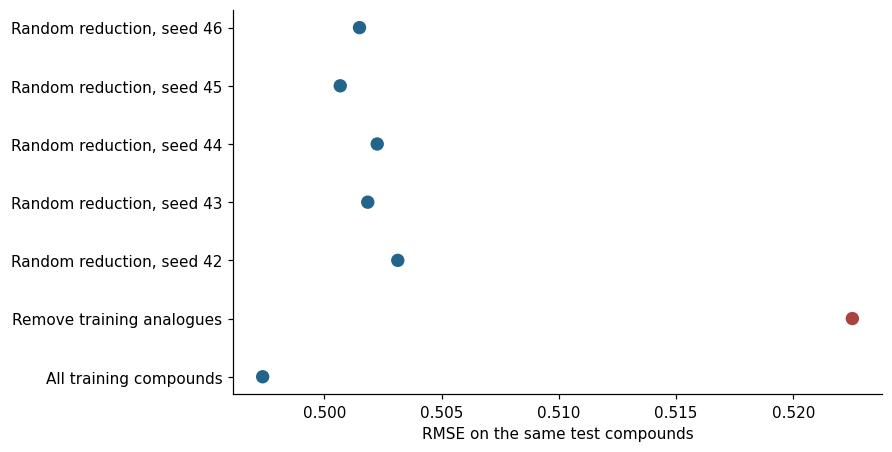

In [5]:
labels = [('Random reduction, seed ' + a.rsplit('seed',1)[1]) if a.startswith('random_') else ('Remove training analogues' if 'remove' in a else 'All training compounds') for a in ab.arm]
fig,ax=plt.subplots(figsize=(8,4),layout='constrained')
ax.scatter(ab.rmse, range(len(ab)), color=['#a94340' if 'remove' in a else '#23658a' for a in ab.arm], s=60)
ax.set(yticks=range(len(ab)), yticklabels=labels, xlabel='RMSE on the same test compounds')
finish(fig,'fixed_test_analogue_control')

## Remaining structural proximity

Disjoint cluster labels do not guarantee a maximum similarity between every pair. Nearest-neighbour Tanimoto is measured directly; this is distinct from the clustering threshold.

,run,role,n,median,p90,maximum,fraction_ge_0_6,fraction_ge_0_8,fraction_equal_1
0,butina03_seed42,calibration,1933,0.55172,0.68293,0.98077,0.36989,0.01655,0.00000
1,butina03_seed42,test,2607,0.57143,0.69444,0.98214,0.43498,0.01880,0.00000
2,butina04_seed42,calibration,2142,0.50000,0.66667,0.97222,0.16993,0.02148,0.00000
3,butina04_seed42,test,2532,0.50000,0.66038,0.93103,0.16311,0.01817,0.00000
4,butina04_seed43,calibration,2005,0.52000,0.70213,0.93333,0.21496,0.02594,0.00000
5,butina04_seed43,test,2459,0.50000,0.66044,0.97436,0.16795,0.02074,0.00000
6,butina04_seed44,calibration,2176,0.51515,0.66667,0.96552,0.17601,0.01838,0.00000
7,butina04_seed44,test,2387,0.51163,0.68920,0.97436,0.18224,0.03016,0.00000
8,butina04_seed45,calibration,2025,0.51163,0.66667,0.93333,0.17975,0.02272,0.00000
9,butina04_seed45,test,2554,0.51724,0.67427,0.93333,0.18285,0.02271,0.00000


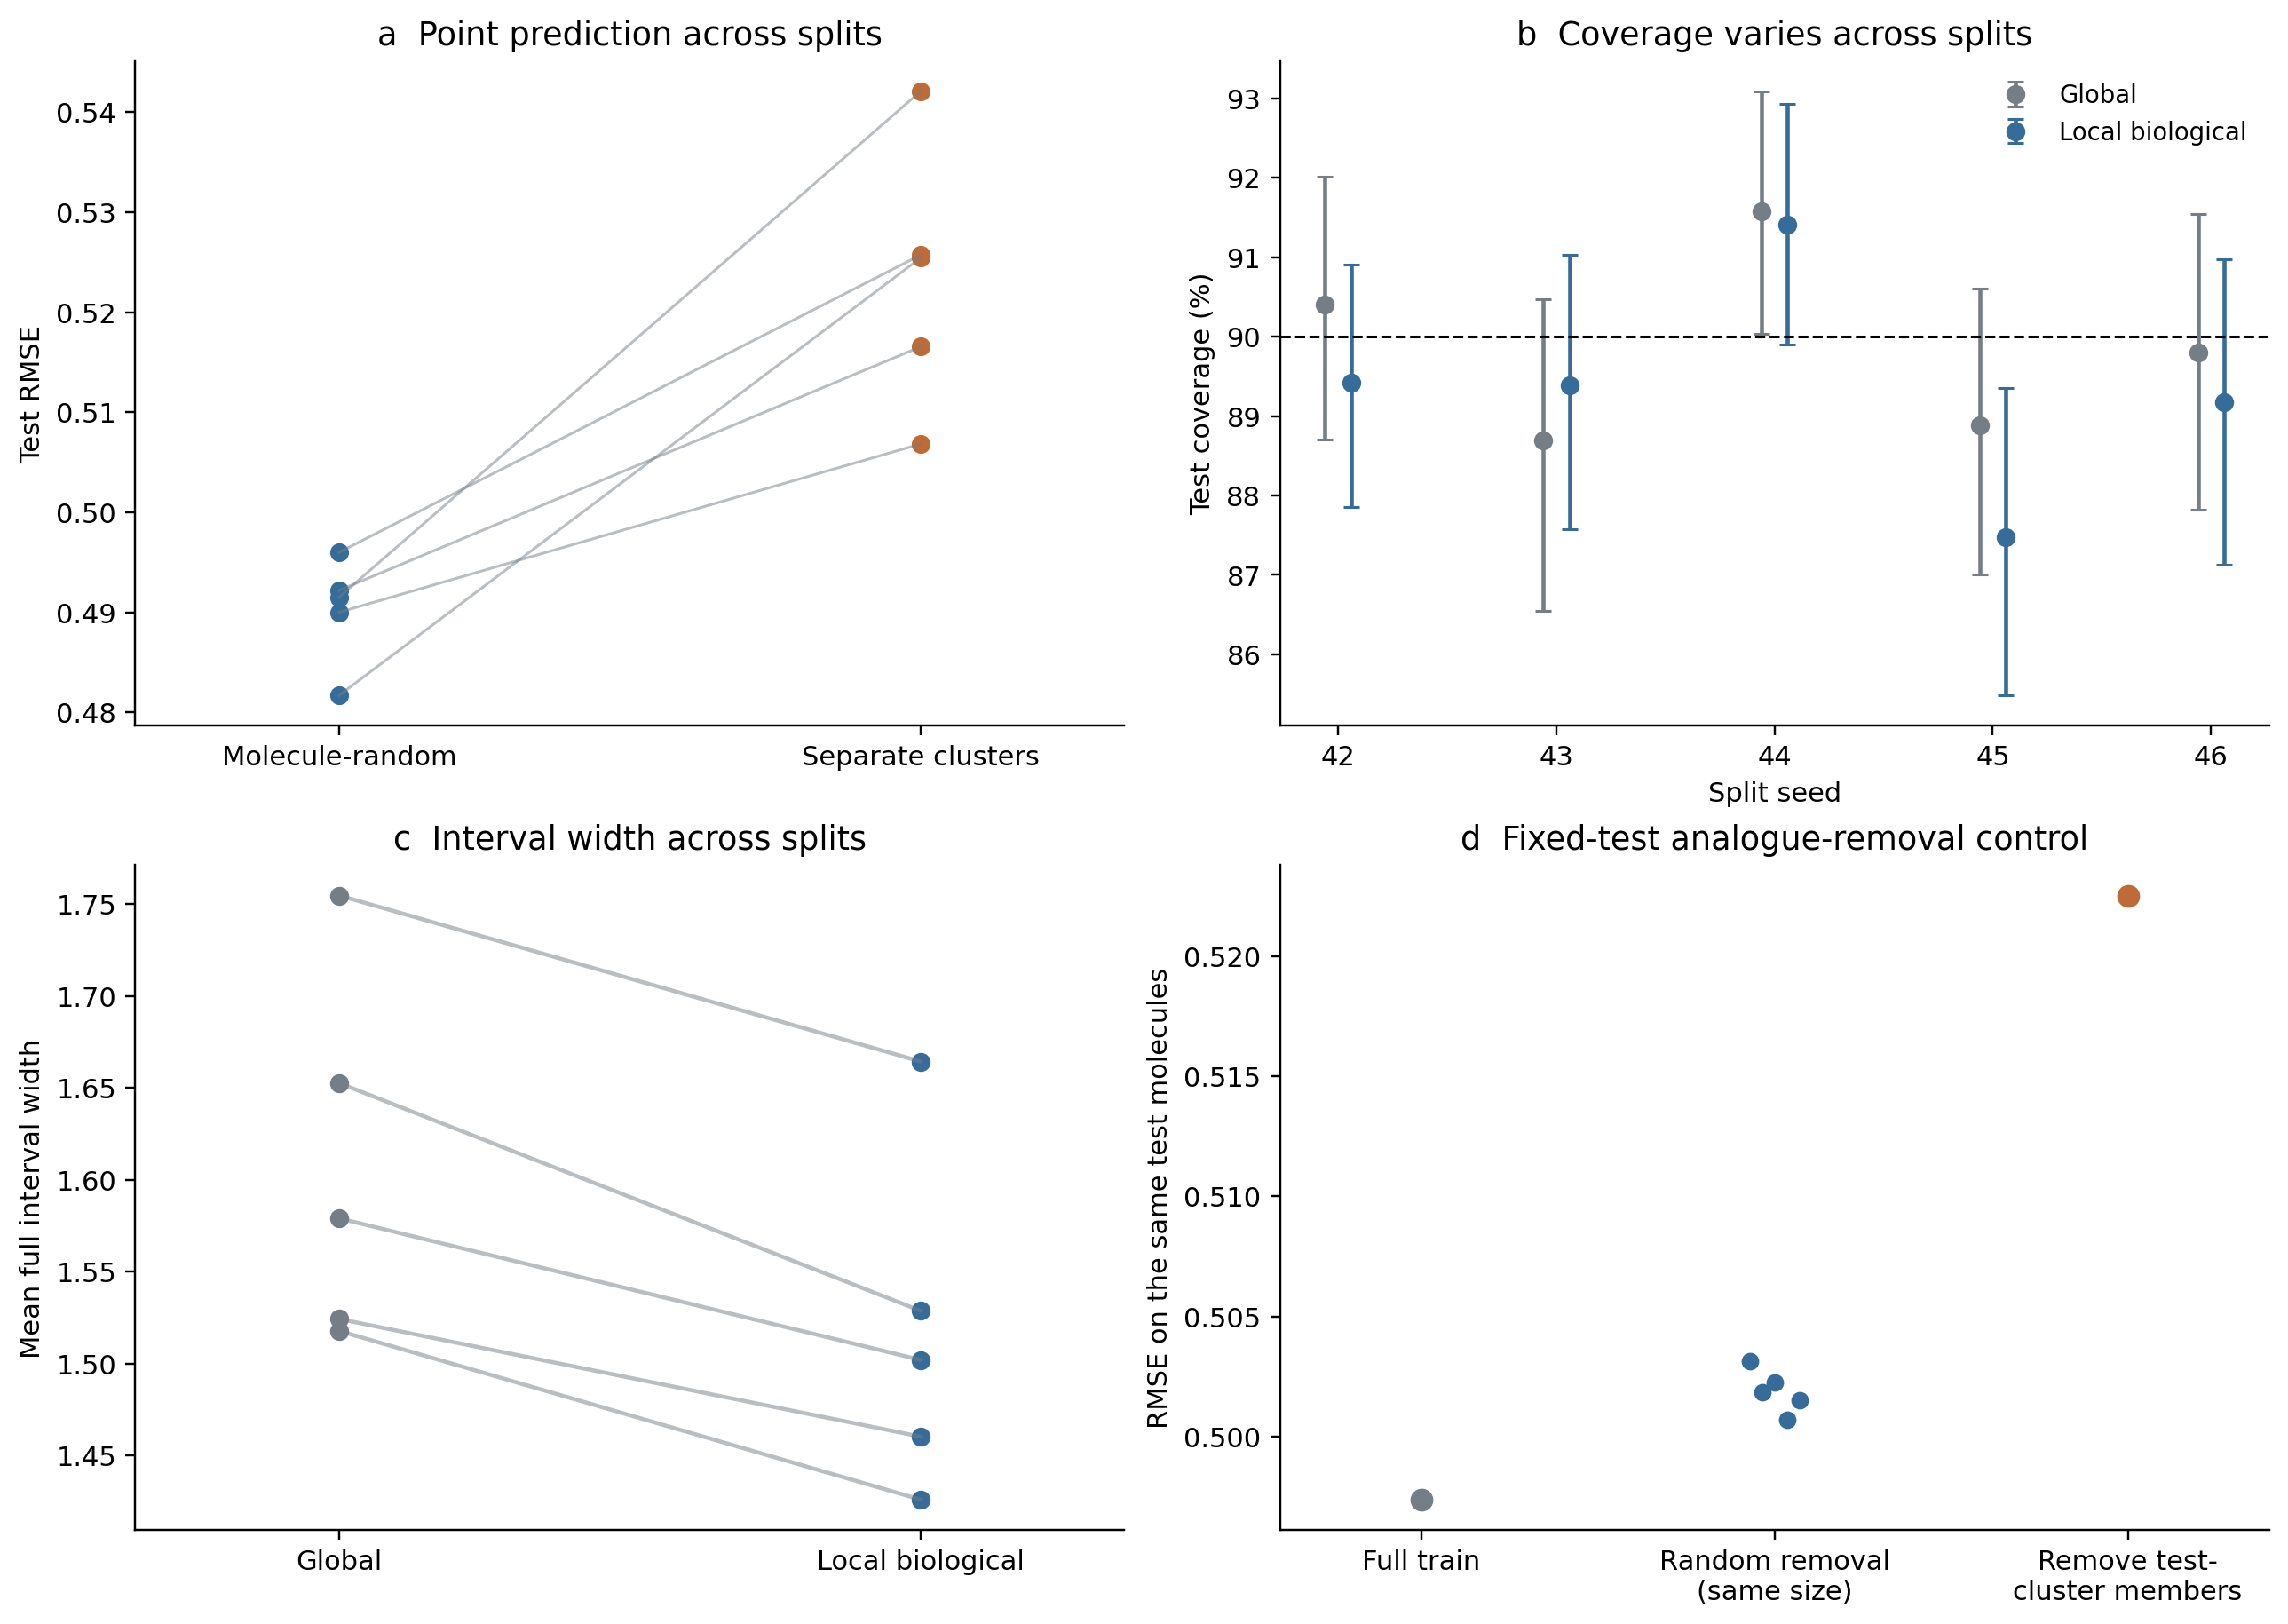

In [6]:
display(table('similarity/summary.csv'))
figure('results/repaired/figures/recalculation_comparison.png')